In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Finds the folder where THIS script lives, then gets its parent (project root)
project_root = Path.cwd().parent
txt_path = project_root / 'data' / 'data.csv'
df = pd.read_csv(txt_path)


1. Overview of the Data:
○ Understand the structure of the dataset, including the number of rows,
columns, and data types.


In [114]:

df.shape

(95662, 16)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [116]:
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
# Convert system IDs to strings so they are treated as categorical variables
id_cols = ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 
           'CustomerId', 'ProviderId', 'ProductId', 'CountryCode']
df[id_cols] = df[id_cols].astype(str)

2. Summary Statistics

Understand the central tendency, dispersion, and shape of the dataset’s
distribution.


In [117]:
df.describe()

,Amount,Value,PricingStrategy,FraudResult
count,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,6.717846e+03,9.900584e+03,2.255974,0.002018
std,1.233068e+05,1.231221e+05,0.732924,0.044872
min,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,2.800000e+03,5.000000e+03,2.000000,0.000000
max,9.880000e+06,9.880000e+06,4.000000,1.000000


In [118]:
# 1. Calculate skewness and kurtosis
skew_vals = df.skew(numeric_only=True)
kurt_vals = df.kurt(numeric_only=True)

# 2. Combine them into a clean summary table
shape_analysis = pd.DataFrame({
    'Skewness': skew_vals,
    'Kurtosis': kurt_vals
})

# 3. Display the results rounded to 2 decimal places
print("=== SHAPE ANALYSIS: SKEWNESS & KURTOSIS ===")
print(shape_analysis.round(2))

=== SHAPE ANALYSIS: SKEWNESS & KURTOSIS ===
                 Skewness  Kurtosis
Amount              51.10   3363.13
Value               51.29   3378.07
PricingStrategy      1.66      2.09
FraudResult         22.20    490.69


3. Distribution of Numerical Features

Visualize the distribution of numerical features to identify patterns, skewness,
and potential outliers.

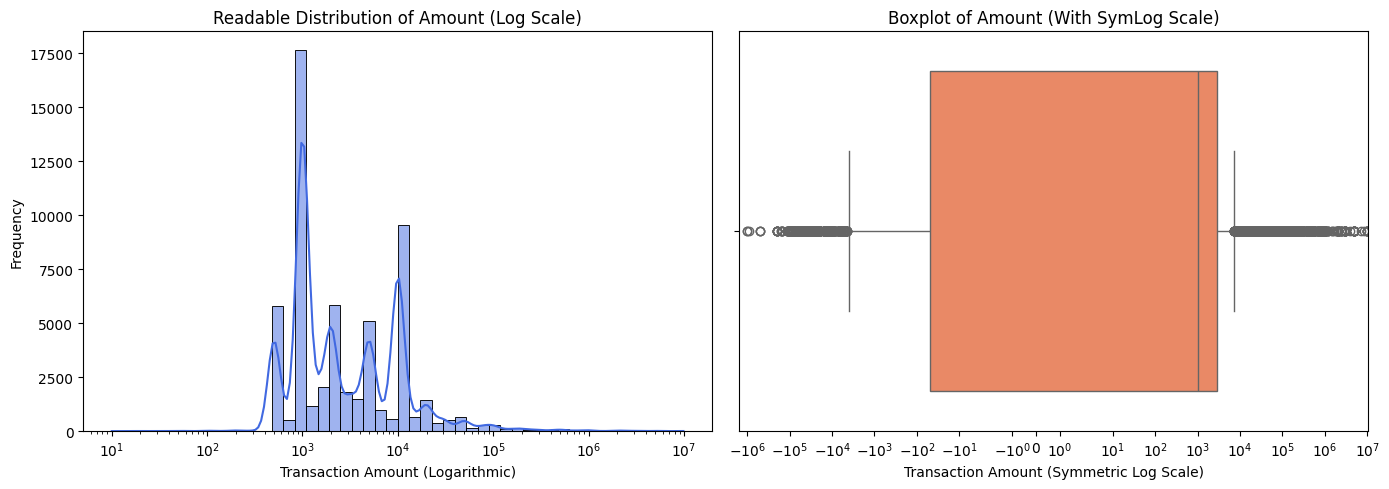

In [119]:
# Set up the side-by-side plot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1HISTOGRAM: Using log_scale=True (Handles positive values cleanly)
positive_amounts = df[df['Amount'] > 0]['Amount']
sns.histplot(positive_amounts, bins=50, kde=True, ax=axes[0], color='royalblue', log_scale=True)
axes[0].set_title('Readable Distribution of Amount (Log Scale)')
axes[0].set_xlabel('Transaction Amount (Logarithmic)')
axes[0].set_ylabel('Frequency')

# 2. BOXPLOT: Using SymLog scale to  handle any negative/zero values
sns.boxplot(x=df['Amount'], ax=axes[1], color='coral')
axes[1].set_xscale('symlog')  # Symlog handles negative numbers, 0, and massive positives
axes[1].set_title('Boxplot of Amount (With SymLog Scale)')
axes[1].set_xlabel('Transaction Amount (Symmetric Log Scale)')

plt.tight_layout()
plt.show()


C:\Users\Hermela\AppData\Local\Temp\ipykernel_840\394938041.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudResult', data=df, palette='Set2')


Text(0.5, 1.0, 'Fraud vs. Legitimate Transaction Counts')

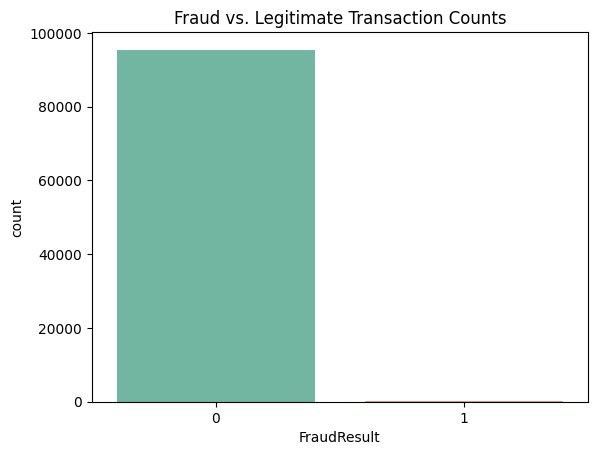

In [120]:
sns.countplot(x='FraudResult', data=df, palette='Set2')
plt.title('Fraud vs. Legitimate Transaction Counts')

The mean of the target variable is 0.002018, indicating that only ~0.2% of the dataset represents fraudulent transactions, while 99.8% are legitimate. Accuracy cannot be used as an evaluation metric; the model will require techniques like SMOTE, down-sampling, or class-weight adjustments to detect the minority fraud class.

We cannot use Accuracy as a model evaluation metric. We must evaluate our models using Precision, Recall, F1-Score, and ROC-AUC. Furthermore, during training, we must apply techniques like SMOTE or adjust algorithmic class weights to ensure the model actually detects the minority fraud class.


Text(0.5, 1.0, 'Log-Scaled Distribution of Transaction Value')

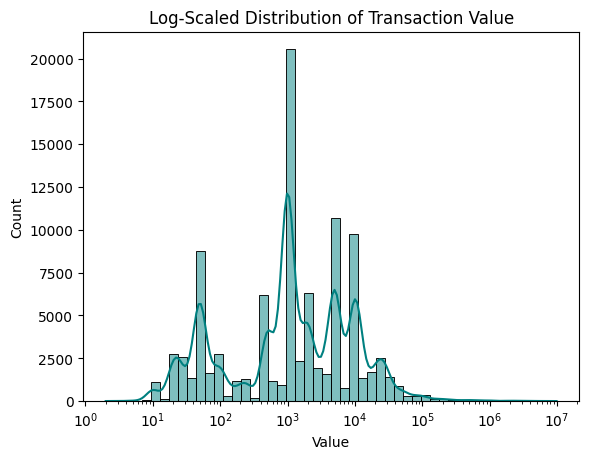

In [121]:
sns.histplot(df['Value'], bins=50, kde=True, log_scale=True, color='teal')
plt.title('Log-Scaled Distribution of Transaction Value')



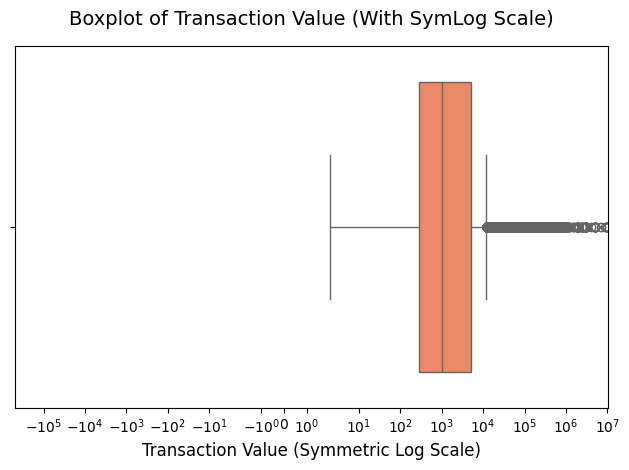

In [122]:
sns.boxplot(x=df['Value'], color='coral')
# 3. Apply SymLog scale to handle the massive range cleanly
plt.xscale('symlog')
# 4. Set accurate titles and labels
plt.title('Boxplot of Transaction Value (With SymLog Scale)', fontsize=14, pad=15)
plt.xlabel('Transaction Value (Symmetric Log Scale)', fontsize=12)

# 5. Clean layout adjustments
plt.tight_layout()
plt.show()


The log-scaled histogram for Value reveals a highly multimodal distribution. Rather than a smooth curve, transaction values cluster into very distinct peaks or "tiers" (e.g., spikes around the 50, 1,000, and 10,000 marks). This suggests distinct pricing tiers or standard top-up amounts.Insight (Outliers): The SymLog boxplots confirm the presence of massive outliers extending past the $10^6$ (1 million) mark.Business Implication: These outliers represent either high-value corporate transfers or extreme anomalies. In the data processing pipeline, these cannot be removed entirely as they may contain critical fraud signals, but they will require robust standardization (such as RobustScaler) to prevent them from mathematically overpowering the machine learning model.

We cannot remove these outliers, as they may contain critical high-value fraud signals. Instead, we must apply a StandardScaler (or RobustScaler) in our preprocessing pipeline to standardize these features. This prevents the massive transaction values from mathematically overpowering the machine learning algorithm.

Text(0.5, 1.0, 'Frequency of Pricing Strategies in the dataset')

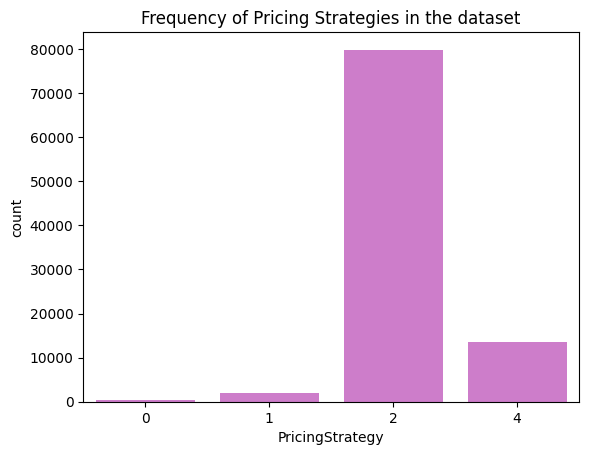

In [123]:
sns.countplot(x='PricingStrategy', data=df, color='orchid')
plt.title('Frequency of Pricing Strategies in the dataset')


Pricing Strategy: Out of the available pricing strategies, Strategy 2 is the standard default, driving roughly 80,000 of the transactions, followed by Strategy 4 (~14,000). Strategies 0 and 1 are rarely utilized.
Business Implication: Because the vast majority of users behave similarly (buying airtime/financial services on Strategy 2), any user who deviates from this standard pathway (e.g., utilizing Strategy 1 for a high-value ticket purchase) will mathematically stand out, potentially serving as a strong predictive signal for the credit scoring model.


4. Distribution of Categorical Features

○ Analyzing the distribution of categorical features provides insights into the
frequency and variability of categories.


5. Correlation Analysis
○ Understanding the relationship between numerical features.

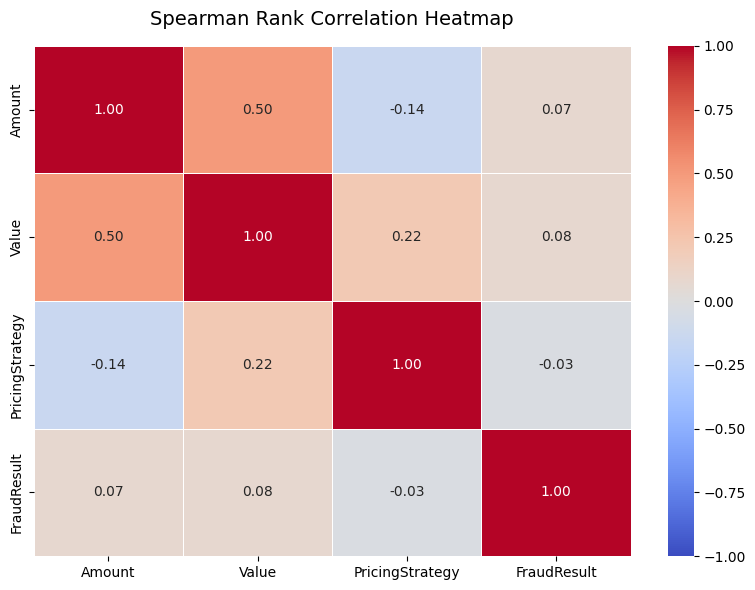

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# 1. Compute Spearman correlation to protect against outlier distortion
corr_matrix = df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr(method='spearman')

# 2. Plot the heatmap with values written inside (annot=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Spearman Rank Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


The target variable (FraudResult) exhibits exceptionally weak correlation with the raw financial metrics, scoring just 0.08 with Value and 0.07 with Amount. This is a critical finding. It proves that fraud and credit default cannot be predicted simply by looking at how large a transaction is. The relationship is non-linear and complex, fully justifying our strategy to engineer sophisticated behavioral features (like RFM metrics and Weight of Evidence) rather than relying on raw transaction amounts.

aw transaction logs are not enough to predict risk. We must engineer Recency, Frequency, and Monetary (RFM) proxy features (e.g., aggregating Total_Amount and Transaction_Count per CustomerId) to capture the historical behavioral footprint of a user.

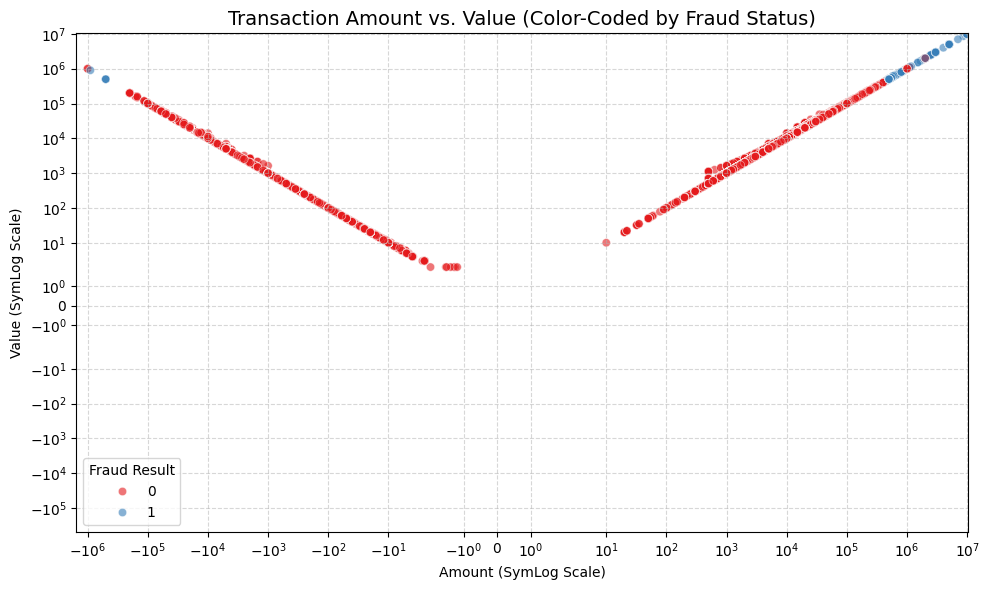

In [125]:
plt.figure(figsize=(10, 6))

# Plot Amount vs Value, colored by FraudResult
sns.scatterplot(x='Amount', y='Value', hue='FraudResult', data=df, palette='Set1', alpha=0.6)

# Apply SymLog scaling so the graph isn't compressed by outliers
plt.xscale('symlog')
plt.yscale('symlog')

plt.title('Transaction Amount vs. Value (Color-Coded by Fraud Status)', fontsize=14)
plt.xlabel('Amount (SymLog Scale)')
plt.ylabel('Value (SymLog Scale)')
plt.legend(title='Fraud Result')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


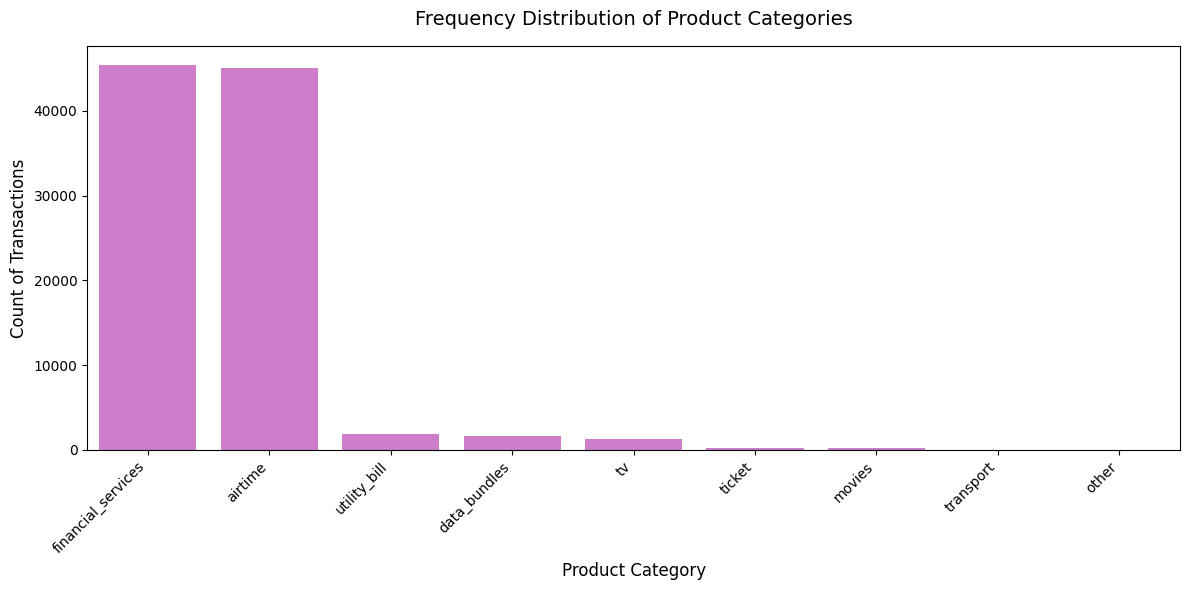

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Enlarge the figure size so categories have plenty of room
plt.figure(figsize=(12, 6))

# 2. Plot the categories sorted from highest count to lowest count
sns.countplot(
    x='ProductCategory', 
    data=df, 
    color='orchid', 
    order=df['ProductCategory'].value_counts().index
)

# 3. ROTATE THE LABELS: This stops text from overlapping
plt.xticks(rotation=45, ha='right')

# 4. Fix the title to match the column
plt.title('Frequency Distribution of Product Categories', fontsize=14, pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)

# 5. Prevent the rotated labels from getting clipped off the bottom edge
plt.tight_layout()
plt.show()


Product Category: The platform's volume is overwhelmingly dominated by just two product categories: financial_services and airtime, which both sit at roughly 45,000 transactions each. Lifestyle purchases like movies, ticket, and transport represent a negligible fraction of overall volume.

6. Identifying Missing Values
○ Identify missing values to determine missing data and decide on appropriate
imputation strategies.


In [127]:
# Count missing values per column
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

print(missing_counts)



TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64


A structural audit of the dataset revealed 100% data completeness across all 95,662 rows, with no standard missing (NaN) values detected in the historical batch. However, to ensure our downstream pipeline is robust against future data drift or missing inputs in a production environment, our treatment strategy will be proactive:

Numerical Features (Amount, Value): We will implement a SimpleImputer using the median strategy to fill any future missing values without skewing the heavy-tailed distribution.

Categorical Features: We will impute missing text with a constant string ('Missing'). This ensures the model can learn if the absence of data is itself a predictive risk signal.

In [128]:
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [129]:
df[["ProviderId", "ProductId", "ChannelId"]].value_counts()

ProviderId    ProductId     ChannelId  
ProviderId_4  ProductId_6   ChannelId_2    32629
ProviderId_6  ProductId_3   ChannelId_3    16091
              ProductId_10  ChannelId_3    10504
ProviderId_5  ProductId_15  ChannelId_3     7321
              ProductId_3   ChannelId_3     3671
                                           ...  
ProviderId_3  ProductId_2   ChannelId_3        1
ProviderId_2  ProductId_1   ChannelId_3        1
ProviderId_1  ProductId_9   ChannelId_1        1
ProviderId_4  ProductId_22  ChannelId_5        1
ProviderId_1  ProductId_10  ChannelId_1        1
Name: count, Length: 140, dtype: int64